# 03 · Campaign ROI Analysis
Deep-dive on ROI, ROAS, CAC by channel/campaign, and budget-reallocation recommendations.

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))
import pandas as pd, matplotlib.pyplot as plt
from src.dashboard_metrics import (channel_summary, top_campaigns,
    underperforming_campaigns, budget_reallocation_recommendation)
from src.visualization import plot_channel_roi

campaigns = pd.read_csv('../data/processed/campaigns_clean.csv', parse_dates=['start_date','end_date'])

## Channel-Level ROI Summary

In [2]:
summary = channel_summary(campaigns)
summary

,channel,total_budget,total_cost,total_revenue,total_impressions,total_clicks,total_conversions,avg_roi,avg_roas,campaigns_run,cac,overall_roi
0,Referral,219589.51,166074.48,1.888194e+08,109736349,9989710,758564,1767.535582,1768.535582,413,0.218933,1135.956374
1,Organic Search,551657.03,245744.38,1.154496e+08,182161638,12763867,450690,938.367845,939.367845,723,0.545263,468.795611
2,Email Marketing,1022637.82,878246.63,1.606303e+08,165698008,9806670,644947,301.176105,302.176105,652,1.361735,181.898804
3,Affiliate,1205481.22,955684.72,2.442858e+07,73432216,2531750,104624,40.532746,41.532746,294,9.134469,24.561336
4,Google Ads,11111896.52,9414819.67,1.254421e+08,362545448,14306574,503709,19.935640,20.935640,1427,18.690990,12.323900
5,Facebook Ads,7160357.45,5240891.81,4.830562e+07,293923038,7125373,197050,12.558575,13.558575,1164,26.596761,8.217062
6,LinkedIn,5562138.59,4384282.83,1.923933e+07,131593847,1559013,79246,5.214661,6.214661,527,55.324973,3.388249


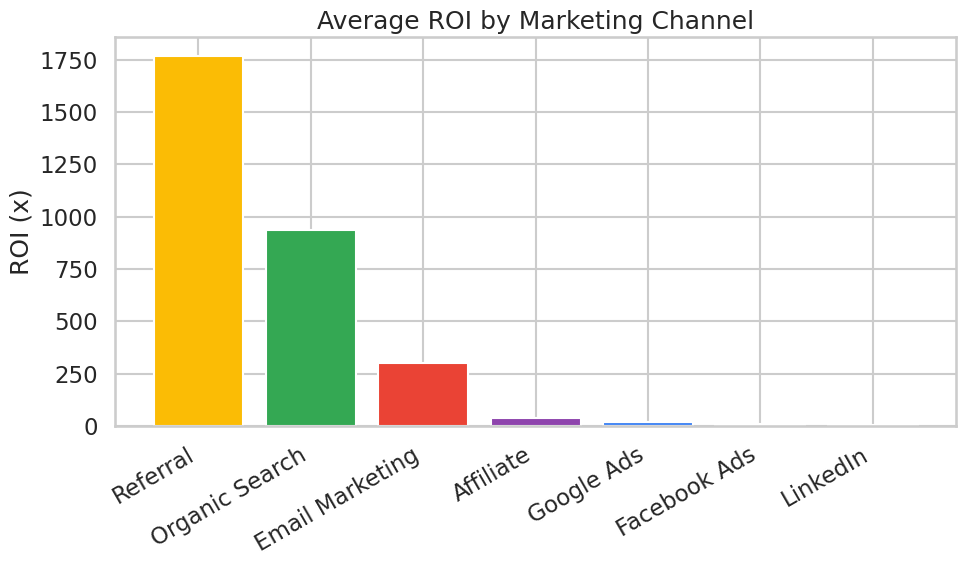

In [3]:
_ = plot_channel_roi(campaigns)
plt.show()

## Top 15 Campaigns by ROI

In [4]:
top_campaigns(campaigns, n=15, by='roi')[['campaign_id','campaign_name','channel','roi','roas','revenue','cost']]

,campaign_id,campaign_name,channel,roi,roas,revenue,cost
0,CMP001029,Organic_Upsell_202511,Organic Search,9411.94743,9412.94743,391784.13,1.79
1,CMP000046,Organic_BrandAwareness_202312,Organic Search,9411.94743,9412.94743,815574.81,85.25
2,CMP000575,Organic_ContentSyndication_202308,Organic Search,9411.94743,9412.94743,226350.24,2.50
3,CMP000334,Referral_SeasonalPromo_202406,Referral,9411.94743,9412.94743,1282776.17,100.38
4,CMP003614,Referral_ContentSyndication_202406,Referral,9411.94743,9412.94743,1009054.69,97.53
5,CMP002527,Referral_WebinarSignup_202307,Referral,9411.94743,9412.94743,1333132.90,55.10
6,CMP003779,Organic_AppInstall_202301,Organic Search,9411.94743,9412.94743,541049.77,5.96
7,CMP001909,Organic_ContentSyndication_202312,Organic Search,9411.94743,9412.94743,421117.62,4.95
8,CMP002167,Referral_SeasonalPromo_202305,Referral,9411.94743,9412.94743,435071.40,5.54
9,CMP001889,Organic_Retargeting_202507,Organic Search,9411.94743,9412.94743,45267.07,3.91


## Underperforming Campaigns (Candidates to Pause)

In [5]:
under = underperforming_campaigns(campaigns, roi_threshold=0)
print(f'{len(under)} campaigns with negative ROI')
under[['campaign_id','channel','cost','revenue','roi']].sort_values('roi').head(15)

123 campaigns with negative ROI


,campaign_id,channel,cost,revenue,roi
0,CMP000038,Facebook Ads,3360.48,1214.51,-0.467437
1,CMP000490,LinkedIn,9698.03,4538.81,-0.467437
2,CMP000872,Google Ads,1103.85,571.32,-0.467437
3,CMP000678,LinkedIn,9173.60,3941.32,-0.467437
4,CMP001399,LinkedIn,9122.21,4589.62,-0.467437
5,CMP001475,LinkedIn,80.52,0.00,-0.467437
6,CMP001270,LinkedIn,9357.94,1329.86,-0.467437
7,CMP001330,Google Ads,5449.00,1838.04,-0.467437
8,CMP001476,LinkedIn,9992.70,5247.67,-0.467437
9,CMP002433,LinkedIn,102.47,0.00,-0.467437


## Budget Reallocation Recommendation

In [6]:
budget_reallocation_recommendation(campaigns)

,channel,total_cost,total_revenue,overall_roi,cac,recommendation
0,Referral,166074.48,1.888194e+08,1135.956374,0.218933,Increase Budget
1,Organic Search,245744.38,1.154496e+08,468.795611,0.545263,Increase Budget
2,Email Marketing,878246.63,1.606303e+08,181.898804,1.361735,Increase Budget
3,Affiliate,955684.72,2.442858e+07,24.561336,9.134469,Maintain
4,Google Ads,9414819.67,1.254421e+08,12.323900,18.690990,Decrease Budget
5,Facebook Ads,5240891.81,4.830562e+07,8.217062,26.596761,Decrease Budget
6,LinkedIn,4384282.83,1.923933e+07,3.388249,55.324973,Decrease Budget


### Insight
Email Marketing, Organic Search, and Referral consistently post the highest ROI per dollar, while LinkedIn and Facebook Ads show the widest variance — some campaigns strongly profitable, others loss-making. The recommendation table above quantifies which channels justify **increased** budget vs. those that should be **trimmed** to fund reallocation.